# Student-Friendly Data Analysis Toolkit

## Overview

This notebook is a beginner-friendly Data Analysis Toolkit designed to help users explore, clean, visualize, and statistically analyze datasets using Python.

The toolkit includes:

- Data exploration
- Missing-value analysis
- Data cleaning
- Descriptive statistics
- Data visualization
- Probability distributions
- Normality testing
- Confidence intervals
- Hypothesis testing
- Exporting cleaned datasets

This toolkit is designed for users with limited programming experience.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Upload

The user can upload any CSV dataset.  
For this demonstration, we use the Students Performance in Exams dataset.

In [2]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    df = pd.read_csv(filename)

print("Dataset uploaded successfully.")
df.head()

Saving StudentsPerformance.csv to StudentsPerformance.csv
Dataset uploaded successfully.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Data Exploration

This section helps users understand the dataset structure, including rows, columns, data types, and first records.

In [3]:
def explore_data(df):
    print("Dataset Shape:")
    print(df.shape)

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())

    print("\nDataset Information:")
    df.info()

In [4]:
explore_data(df)

Dataset Shape:
(1000, 8)

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

First 5 Rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## 3. Missing-Value Analysis

This section checks if the dataset contains missing values and shows the percentage of missing data in each column.

In [5]:
def missing_value_analysis(df):
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100

    result = pd.DataFrame({
        "Missing Values": missing_values,
        "Missing Percentage": missing_percentage
    })

    return result

In [6]:
missing_value_analysis(df)

,Missing Values,Missing Percentage
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0


## 4. Data Cleaning

This section removes duplicate rows and handles missing values.  
The user can choose one of three methods:

- `drop`: remove rows with missing values
- `mean`: replace missing numerical values with the mean
- `median`: replace missing numerical values with the median

In [7]:
def clean_data(df, method="drop"):
    df_cleaned = df.copy()

    print("Duplicate rows before cleaning:", df_cleaned.duplicated().sum())

    df_cleaned = df_cleaned.drop_duplicates()

    if method == "drop":
        df_cleaned = df_cleaned.dropna()

    elif method == "mean":
        numeric_cols = df_cleaned.select_dtypes(include=np.number).columns
        df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].mean())

    elif method == "median":
        numeric_cols = df_cleaned.select_dtypes(include=np.number).columns
        df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

    else:
        print("Invalid method. Please choose: drop, mean, or median.")

    print("Duplicate rows after cleaning:", df_cleaned.duplicated().sum())
    print("New dataset shape:", df_cleaned.shape)

    return df_cleaned

In [8]:
df_cleaned = clean_data(df, method="mean")

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
New dataset shape: (1000, 8)


## 5. Descriptive Statistics

This section calculates important statistical measures such as mean, median, mode, variance, standard deviation, skewness, and kurtosis.

In [9]:
def descriptive_statistics(df):
    numeric_df = df.select_dtypes(include=np.number)

    summary = pd.DataFrame({
        "Mean": numeric_df.mean(),
        "Median": numeric_df.median(),
        "Mode": numeric_df.mode().iloc[0],
        "Minimum": numeric_df.min(),
        "Maximum": numeric_df.max(),
        "Variance": numeric_df.var(),
        "Standard Deviation": numeric_df.std(),
        "Skewness": numeric_df.skew(),
        "Kurtosis": numeric_df.kurtosis()
    })

    return summary

In [10]:
descriptive_statistics(df_cleaned)

,Mean,Median,Mode,Minimum,Maximum,Variance,Standard Deviation,Skewness,Kurtosis
math score,66.089,66.0,65,0,100,229.918998,15.163080,-0.278935,0.274964
reading score,69.169,70.0,72,17,100,213.165605,14.600192,-0.259105,-0.068265
writing score,68.054,69.0,74,10,100,230.907992,15.195657,-0.289444,-0.033365


## 6. Automatic Column Detection

This section automatically detects numerical and categorical columns.

In [11]:
numeric_columns = df_cleaned.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df_cleaned.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['math score', 'reading score', 'writing score']

Categorical Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## 7. Data Visualization

This section creates common plots used in data analysis:

- Histograms
- Boxplots
- Scatter plots
- Bar charts

In [12]:
def plot_histogram(df, column):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


def plot_boxplot(df, column):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()


def plot_scatter(df, x_column, y_column):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=x_column, y=y_column)
    plt.title(f"{x_column} vs {y_column}")
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.show()


def plot_bar_chart(df, column):
    plt.figure(figsize=(8, 5))
    df[column].value_counts().plot(kind="bar")
    plt.title(f"Bar Chart of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

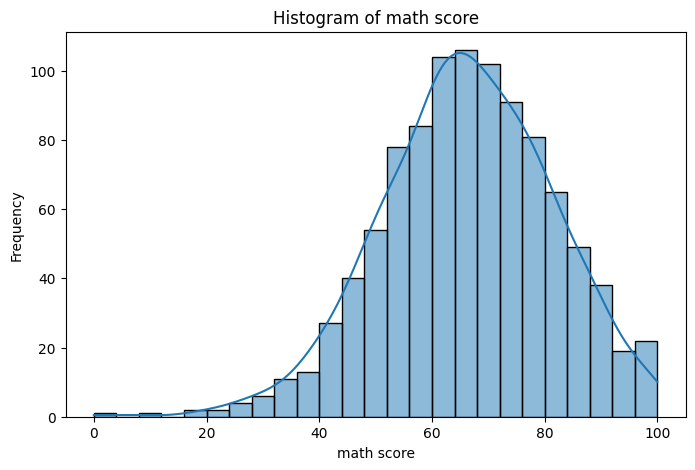

In [13]:
plot_histogram(df_cleaned, "math score")

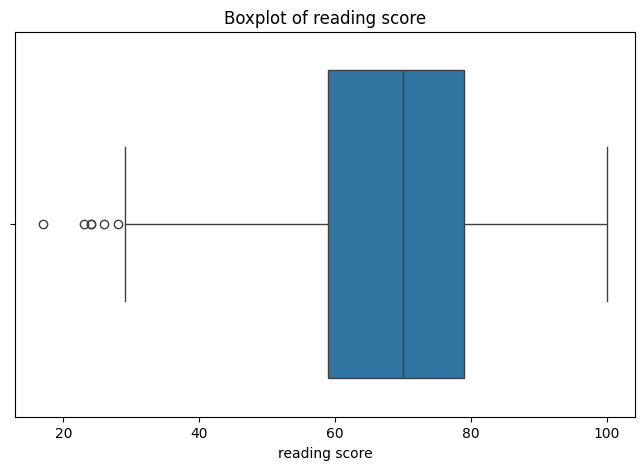

In [14]:
plot_boxplot(df_cleaned, "reading score")

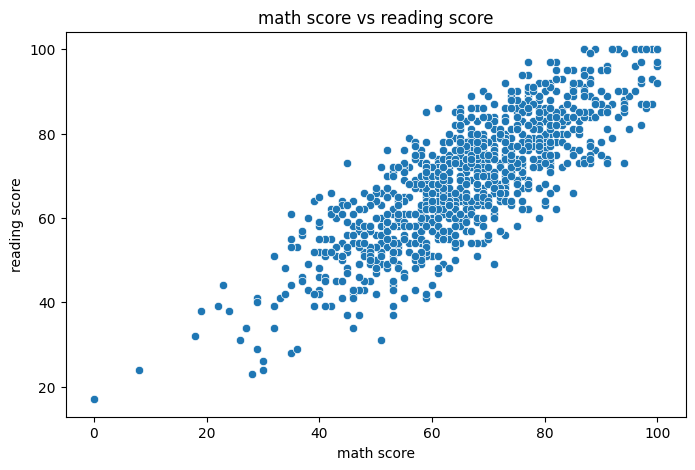

In [15]:
plot_scatter(df_cleaned, "math score", "reading score")

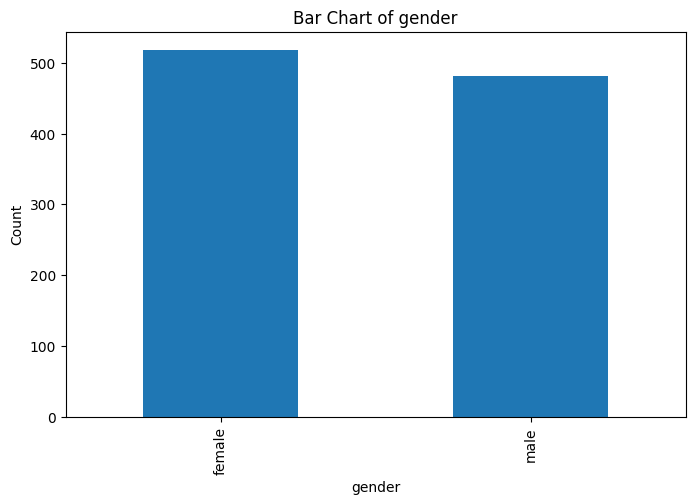

In [16]:
plot_bar_chart(df_cleaned, "gender")

## 8. Probability Distributions

This section helps users understand probability distributions using:

- PDF: Probability Density Function
- CDF: Cumulative Distribution Function

The PDF shows where values are more likely to occur.  
The CDF shows the probability of getting a value less than or equal to a specific value.

In [17]:
def plot_pdf_cdf(df, column):
    data = df[column].dropna()

    mean = data.mean()
    std = data.std()

    x = np.linspace(data.min(), data.max(), 100)

    pdf = stats.norm.pdf(x, mean, std)
    cdf = stats.norm.cdf(x, mean, std)

    plt.figure(figsize=(8, 5))
    plt.plot(x, pdf)
    plt.title(f"Normal Distribution PDF of {column}")
    plt.xlabel(column)
    plt.ylabel("Probability Density")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(x, cdf)
    plt.title(f"Normal Distribution CDF of {column}")
    plt.xlabel(column)
    plt.ylabel("Cumulative Probability")
    plt.show()

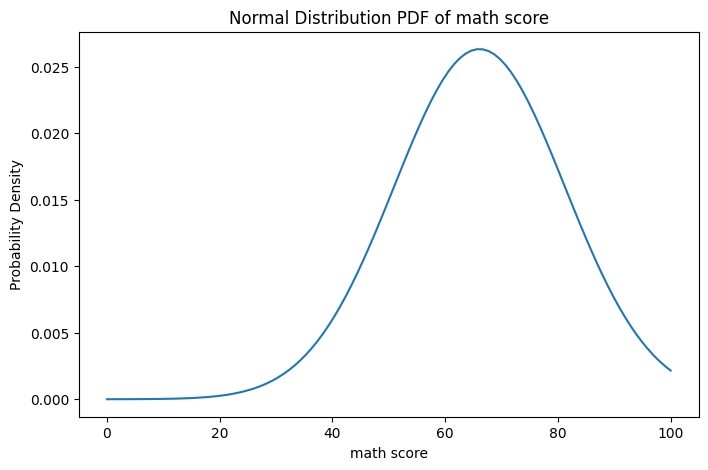

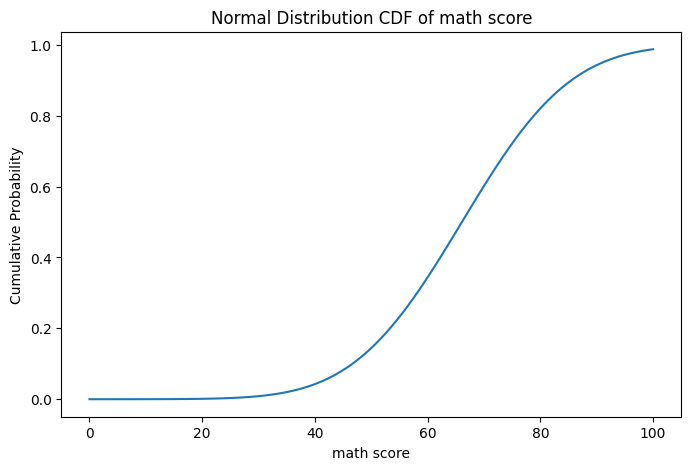

In [18]:
plot_pdf_cdf(df_cleaned, "math score")

## 9. Normality Testing

Normality testing checks whether a numerical variable follows a normal distribution.

We use the Shapiro-Wilk test.

Interpretation:

- If p-value > 0.05: the data may be normally distributed.
- If p-value ≤ 0.05: the data probably does not follow a normal distribution.

In [19]:
def normality_test(df, column):
    data = df[column].dropna()

    stat, p_value = stats.shapiro(data)

    print("Shapiro-Wilk Normality Test")
    print("Statistic:", stat)
    print("P-value:", p_value)

    if p_value > 0.05:
        print("Interpretation: The data may be normally distributed.")
    else:
        print("Interpretation: The data does not appear to be normally distributed.")

In [20]:
normality_test(df_cleaned, "math score")

Shapiro-Wilk Normality Test
Statistic: 0.9931513872437832
P-value: 0.00014545719606603633
Interpretation: The data does not appear to be normally distributed.


## 10. Confidence Interval

A confidence interval gives a range of likely values for the true population mean.

For example, a 95% confidence interval means we are 95% confident that the true mean is inside the calculated interval.

In [21]:
def confidence_interval(df, column, confidence=0.95):
    data = df[column].dropna()

    mean = np.mean(data)
    sem = stats.sem(data)

    interval = stats.t.interval(
        confidence,
        len(data) - 1,
        loc=mean,
        scale=sem
    )

    print(f"{confidence*100}% Confidence Interval for {column}:")
    print(interval)

In [22]:
confidence_interval(df_cleaned, "math score")

95.0% Confidence Interval for math score:
(np.float64(65.14805983128305), np.float64(67.02994016871695))


## 11. Hypothesis Testing

Hypothesis testing helps us make decisions using data.

This toolkit includes:

- One-sample t-test
- Chi-square test

In [23]:
def one_sample_t_test(df, column, population_mean):
    data = df[column].dropna()

    stat, p_value = stats.ttest_1samp(data, population_mean)

    print("One-Sample T-Test")
    print("T-statistic:", stat)
    print("P-value:", p_value)

    if p_value < 0.05:
        print("Interpretation: Reject the null hypothesis.")
    else:
        print("Interpretation: Fail to reject the null hypothesis.")


def chi_square_test(df, column1, column2):
    table = pd.crosstab(df[column1], df[column2])

    stat, p_value, dof, expected = stats.chi2_contingency(table)

    print("Chi-Square Test")
    print("Chi-square statistic:", stat)
    print("P-value:", p_value)
    print("Degrees of freedom:", dof)

    if p_value < 0.05:
        print("Interpretation: There is a significant relationship between the two variables.")
    else:
        print("Interpretation: There is no significant relationship between the two variables.")

In [24]:
one_sample_t_test(df_cleaned, "math score", 70)

One-Sample T-Test
T-statistic: -8.156435137590153
P-value: 1.0291264341623114e-15
Interpretation: Reject the null hypothesis.


In [25]:
chi_square_test(df_cleaned, "gender", "test preparation course")

Chi-Square Test
Chi-square statistic: 0.015529201882465888
P-value: 0.9008273880804724
Degrees of freedom: 1
Interpretation: There is no significant relationship between the two variables.


## 12. Export Results

This section allows users to export the cleaned dataset as a CSV file.

In [26]:
def export_cleaned_data(df, filename="cleaned_dataset.csv"):
    df.to_csv(filename, index=False)
    print(f"Cleaned dataset exported as {filename}")

In [27]:
export_cleaned_data(df_cleaned)

Cleaned dataset exported as cleaned_dataset.csv


In [28]:
files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Example Analysis Summary

In this demonstration, the Students Performance dataset was used.

The toolkit first explored the structure of the dataset, including the number of rows, columns, data types, and first records.  
Then, missing values and duplicate rows were checked.  
After that, descriptive statistics were calculated for numerical variables such as math score, reading score, and writing score.

The toolkit also generated visualizations such as histograms, boxplots, scatter plots, and bar charts.  
Probability distribution tools were used to display the PDF and CDF of the math score column.

Finally, statistical inference methods were applied, including normality testing, confidence intervals, a one-sample t-test, and a chi-square test.

This shows that the toolkit can help beginner users perform a complete basic data analysis workflow.